# Deep Hedging under GBM and Heston Stochastic Volatility

**Author/Contributor:** Antareep Gogoi  
**Primary question:** Can neural-network hedge policies improve lower-tail hedging performance relative to model-based delta hedges once transaction costs are included?

This notebook follows the deep-hedging framework of Bühler et al., in which a neural network represents a dynamic hedge policy and is trained directly against a risk-adjusted terminal gain objective [Buehler2019, BuehlerHorvath2022].

The notebook has two parts:

1. **GBM / Black-Scholes sanity checks** at zero and non-zero transaction costs, using analytical Black-Scholes delta as the classical baseline [BlackScholes1973].
2. **Heston stochastic-volatility experiments** at proportional transaction cost $\gamma\in\{0,0.001,0.005\}$, comparing the following three strategies:
   - analytical Heston stock delta,
   - Simple NN deep hedging,
   - Recurrent NN deep hedging.

The Heston delta is computed from the semi-analytical Heston characteristic-function representation [Heston1993]. The neural networks are trained separately at each transaction-cost level using the following loss function:

$$
\boxed{\text{Loss}=\text{Score}=-\operatorname{CVaR}_{50\%}(G)},
$$

where $G$ is raw terminal net hedging gain after option payoff and transaction costs, and CVaR stands for conditional value at risk. **Lower score is better.**

## The Heston Model
In a realistic market, the volatility of stocks and options prices can be stochatic and is well described by the Heston market model [Heston1993]. The stock price in a Heston market is governed by the following equations:
$$
dS_t = \mu S_t \, dt + \sqrt{v_t}S_t \, dW_t^S, \\
dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_t^v, \\
dW^S_t \, dW^v_t = \rho \, dt,
$$
where $S_t$ is the underlying asset price at time, $v_t$ is the instantaneous variance, $\theta$ is the long-run average variance, $\kappa$ is the speed of mean reversion of variance toward $\theta$, $\xi$ is the volatility of volatility, $\rho$ is the instantaneous correlation between the Brownian motions $W_t^S$ and $W^v_t$, and $\mu$ is the drift.

In a Heston market with stochastic volatility, the instantaneous variance process $v_t$ is a latent model state; it is not directly quoted in the market. Passing the simulator's exact $v_t$ to the neural networks would give them privileged information that a live strategy would not normally observe. Therefore, the Heston NNs use a causal **EWMA variance proxy** computed only from stock returns available through the current hedge date [RiskMetrics1996]:

$$
\hat v_0=\sigma_0^2,
\qquad
\hat v_t
=
\lambda_{\mathrm{EWMA}}\hat v_{t-1}
+
(1-\lambda_{\mathrm{EWMA}})
\frac{\log^2(S_t/S_{t-1})}{\Delta t},
$$

with $\lambda_{\mathrm{EWMA}}=0.94$.

The policy inputs are:

- **Simple NN:**
  $$
  \left[
  \log(S_t/K),\;\tau_t/T,\;\sqrt{\hat v_t}/\sigma_0
  \right].
  $$
- **Recurrent NN:**
  $$
  \left[
  \log(S_t/K),\;\tau_t/T,\;\sqrt{\hat v_t}/\sigma_0,\;\delta_{t-1}
  \right].
  $$

The analytical Heston delta still uses the simulator's true $v_t$, so it is explicitly interpreted as an **oracle, model-consistent benchmark**. This gives the analytical baseline an informational advantage and makes the comparison conservative for the neural networks.

## Methodology: Terminal gain, transaction costs, and score

For a short European call with stock position $\delta_t$, terminal net gain is

$$
G
=
V_0-(S_T-K)^+
+
\sum_{t=0}^{N-1}
\delta_t(S_{t+1}-S_t)
-
C_T,
$$

where the proportional transaction cost is

$$
C_T
=
\gamma
\sum_{t=0}^{N-1}
S_t\left|\delta_t-\delta_{t-1}\right|
+
\gamma S_T\left|\delta_{N-1}\right|.
$$

The final term is the cost of liquidating the remaining stock hedge at maturity. This is a stock-only specialization of the transaction-cost framework in deep hedging [Buehler2019].

For gains, the lower-tail CVaR representation is

$$
\operatorname{CVaR}_{\alpha}(G)
=
\sup_w
\left[
 w-
 \frac{1}{1-\alpha}
 \mathbb E[(w-G)^+]
\right].
$$

PyTorch minimizes the negative of this quantity. With $\alpha=0.50$, the empirical score is the negative average of the lowest 50% of out-of-sample terminal gains:

$$
\boxed{
\text{Score}
=-\operatorname{CVaR}_{50\%}(G)
}.
$$

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if (HERE / "src").exists():
    ROOT = HERE
elif (HERE.parent / "src").exists():
    ROOT = HERE.parent
else:
    raise RuntimeError("Launch this notebook from the repository root or notebooks/ folder.")

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(min(torch.get_num_threads(), 4))

from src.deep_hedging_gbm_heston import (
    ExperimentConfig,
    initial_bs_price,
    initial_heston_price,
    simulate_gbm,
    simulate_heston,
    ewma_variance_proxy,
    heston_delta_path,
    cost_sweep_table,
)
from src.deep_hedging_gbm_heston.plots import (
    plot_heston_cost_sweep_density,
)
from scripts.run_gbm_heston_experiments import (
    run_gbm_scenario,
    run_heston_scenario,
)

OUTPUT_DIR = ROOT / "outputs"
for subdir in ["figures", "tables", "models"]:
    (OUTPUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

## Experiment configuration

The full experiment trains the Simple and Recurrent Heston policies **separately at each cost level**, giving six Heston training runs. All strategies and cost levels are evaluated on the same held-out Heston paths.

In [2]:
RUN_FULL_EXPERIMENT = True #Change this to False for a simple smoke test

if RUN_FULL_EXPERIMENT:
    BASE = ExperimentConfig(
        epochs=250,
        batch_size=4096,
        eval_paths=100_000,
        seed=123,
    )
    HESTON_QUAD_NODES = 64
else:
    BASE = ExperimentConfig(
        epochs=3,
        batch_size=256,
        eval_paths=1_000,
        seed=123,
    )
    HESTON_QUAD_NODES = 32

COST_GAMMAS = (0.0, 0.001, 0.005)

print(BASE)
print(f"\nInitial Black-Scholes premium: {initial_bs_price(BASE):.6f}")
print(f"Initial Heston premium:        {initial_heston_price(BASE):.6f}")

ExperimentConfig(S0=100.0, K=100.0, sigma=0.2, mu=0.0, r=0.0, T=0.0821917808219178, N=22, cost_gamma=0.0, cvar_confidence=0.5, ewma_decay=0.94, variance_floor=1e-08, hidden=15, batch_size=4096, epochs=250, lr=0.005, grad_clip=10.0, eval_paths=100000, seed=123, device='cpu', heston_kappa=3.0, heston_theta=0.04000000000000001, heston_xi=0.6, heston_rho=-0.7)

Initial Black-Scholes premium: 2.287148
Initial Heston premium:        2.222903


## Sanity checks

The first check verifies the score convention. For gains \([-4,-2,1,3]\), the worst half is \([-4,-2]\), so $operatorname{CVaR}_{50\%}=-3$ and the score is \(+3\).

The second check verifies that the EWMA state is causal: changing prices from day 10 onward must not alter variance estimates before day 10.

In [3]:
from src.deep_hedging_gbm_heston import negative_cvar_score

test_gain = np.array([-4.0, -2.0, 1.0, 3.0])
assert np.isclose(negative_cvar_score(test_gain, confidence=0.50), 3.0)

cfg_check = BASE.with_updates(eval_paths=100)
torch.manual_seed(BASE.seed + 999)
S_check, _ = simulate_heston(100, cfg_check)
S_changed = S_check.clone()
S_changed[:, 10:] *= 1.20

v_hat_original = ewma_variance_proxy(S_check, cfg_check)
v_hat_changed = ewma_variance_proxy(S_changed, cfg_check)
assert torch.allclose(v_hat_original[:, :10], v_hat_changed[:, :10])

print("Score convention: PASS")
print("EWMA no-look-ahead test: PASS")

Score convention: PASS
EWMA no-look-ahead test: PASS


# Part I — GBM / Black-Scholes baseline

These experiments are done as a validation sequence. Under GBM and no transaction costs, analytical Black-Scholes delta is the natural benchmark [BlackScholes1973]. With transaction costs, the Recurrent NN can condition its next hedge on its current holdings and potentially avoid unnecessary trading [Buehler2019].


GBM MARKET: gamma=0

Training Simple NN: GBM gamma=0
Simple NN              epoch    1/250, -CVaR loss=1.431971, threshold=0.005000
Simple NN              epoch   50/250, -CVaR loss=1.350444, threshold=0.221226
Simple NN              epoch  100/250, -CVaR loss=1.145794, threshold=0.287738
Simple NN              epoch  150/250, -CVaR loss=0.702191, threshold=0.125078
Simple NN              epoch  200/250, -CVaR loss=0.434458, threshold=0.027802
Simple NN              epoch  250/250, -CVaR loss=0.352956, threshold=0.023576

Training Recurrent NN: GBM gamma=0
Recurrent NN           epoch    1/250, -CVaR loss=1.446846, threshold=0.005000
Recurrent NN           epoch   50/250, -CVaR loss=1.351296, threshold=0.220816
Recurrent NN           epoch  100/250, -CVaR loss=1.144464, threshold=0.288621
Recurrent NN           epoch  150/250, -CVaR loss=0.558223, threshold=0.078774
Recurrent NN           epoch  200/250, -CVaR loss=0.451955, threshold=0.033043
Recurrent NN           epoch  250/250, -C

,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,0.312089,-0.312089,0.001928,0.415968,0.415970,0.0,2.457386
Simple NN,0.355480,-0.355480,0.001533,0.463713,0.463714,0.0,2.451576
Recurrent NN,0.386342,-0.386342,0.001832,0.506897,0.506898,0.0,2.125058



GBM MARKET: gamma=0.005

Training Simple NN: GBM gamma=0.005
Simple NN              epoch    1/250, -CVaR loss=2.299254, threshold=-0.005000
Simple NN              epoch   50/250, -CVaR loss=1.867451, threshold=-0.136130
Simple NN              epoch  100/250, -CVaR loss=1.810255, threshold=-0.122152
Simple NN              epoch  150/250, -CVaR loss=1.847931, threshold=-0.080650
Simple NN              epoch  200/250, -CVaR loss=1.857944, threshold=-0.058911
Simple NN              epoch  250/250, -CVaR loss=1.725643, threshold=-0.017324

Training Recurrent NN: GBM gamma=0.005
Recurrent NN           epoch    1/250, -CVaR loss=2.650179, threshold=-0.005000
Recurrent NN           epoch   50/250, -CVaR loss=1.875764, threshold=-0.132289
Recurrent NN           epoch  100/250, -CVaR loss=1.816693, threshold=-0.132531
Recurrent NN           epoch  150/250, -CVaR loss=1.851747, threshold=-0.102305
Recurrent NN           epoch  200/250, -CVaR loss=1.854598, threshold=-0.084863
Recurrent NN      

,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
Strategy,,,,,,,
Black-Scholes delta,1.691345,-1.691345,-1.237325,0.582934,1.367765,1.239253,2.457386
Recurrent NN,1.764175,-1.764175,-0.430957,1.761734,1.813670,0.440038,0.879681
Simple NN,1.766303,-1.766303,-0.414651,1.800014,1.847147,0.423093,0.845643


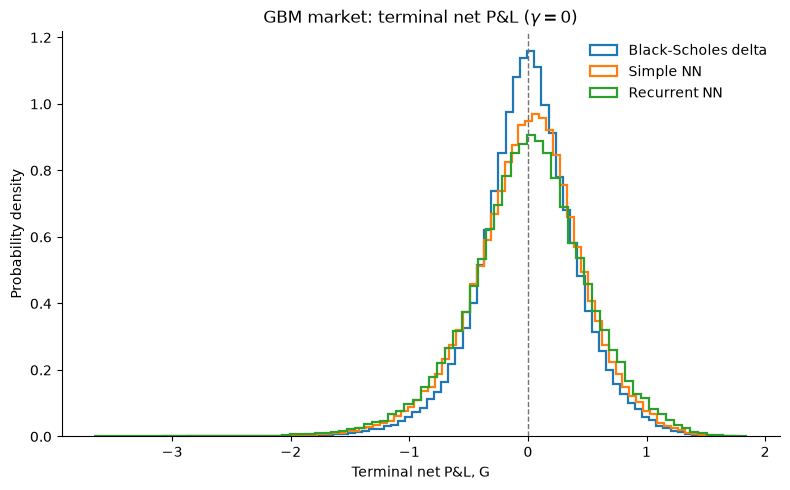

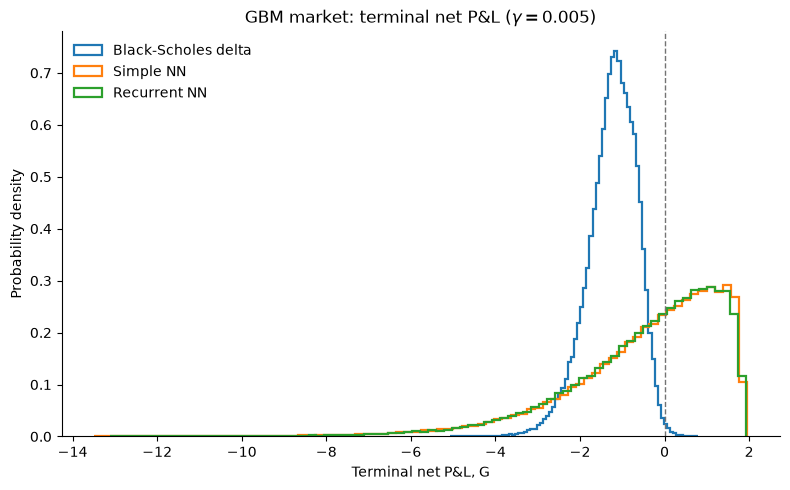

In [4]:
torch.manual_seed(BASE.seed + 10_000)
S_GBM_TEST = simulate_gbm(BASE.eval_paths, BASE)

gbm_experiments = {}
for gamma in (0.0, 0.005):
    cfg = BASE.with_updates(cost_gamma=gamma)
    print("\n" + "=" * 72)
    print(f"GBM MARKET: gamma={gamma:g}")
    print("=" * 72)
    experiment = run_gbm_scenario(
        cfg,
        S_GBM_TEST,
        label=f"GBM gamma={gamma:g}",
        output_dir=OUTPUT_DIR,
    )
    gbm_experiments[gamma] = experiment
    display(experiment["table"])

# Part II — Heston market cost sweep

This analysis on the Heston market compares the following three strategies for three different rates of transaction cost:

1. Analytical Heston delta — oracle model benchmark using true simulated $v_t$.
2. Simple NN — uses observable EWMA variance $\hat v_t$.
3. Recurrent NN — uses observable EWMA variance $\hat v_t$ and previous hedge $\delta_{t-1}$.

The same held-out Heston paths are used at all three transaction-cost levels. The analytical Heston delta path is computed once because its stock positions do not depend on $\gamma$; only the realized transaction-cost deduction changes.

In [5]:
torch.manual_seed(BASE.seed + 20_000)
S_HESTON_TEST, V_TRUE_TEST = simulate_heston(BASE.eval_paths, BASE)
V_HAT_TEST = ewma_variance_proxy(S_HESTON_TEST, BASE)

print("Computing analytical Heston delta positions once...")
HESTON_DELTA_PATH = heston_delta_path(
    S_HESTON_TEST,
    V_TRUE_TEST,
    BASE,
    n_quad=HESTON_QUAD_NODES,
)

print("Test stock paths:        ", tuple(S_HESTON_TEST.shape))
print("True latent variance:    ", tuple(V_TRUE_TEST.shape))
print("Observable EWMA variance:", tuple(V_HAT_TEST.shape))
print("Heston delta positions:  ", tuple(HESTON_DELTA_PATH.shape))

Computing analytical Heston delta positions once...
Test stock paths:         (100000, 23)
True latent variance:     (100000, 23)
Observable EWMA variance: (100000, 23)
Heston delta positions:   (100000, 22)


In [6]:
heston_cost_sweep = {}

for gamma in COST_GAMMAS:
    cfg = BASE.with_updates(cost_gamma=gamma)

    print("\n" + "=" * 72)
    print(f"HESTON MARKET: gamma={gamma:g}")
    print("=" * 72)

    experiment = run_heston_scenario(
        cfg,
        (S_HESTON_TEST, V_TRUE_TEST),
        analytical_delta_path=HESTON_DELTA_PATH,
        label=f"Heston gamma={gamma:g}",
        output_dir=OUTPUT_DIR,
    )

    # Guard against accidentally reintroducing a BS row into the Heston section.
    assert tuple(experiment["results"]) == (
        "Analytical Heston delta",
        "Simple NN",
        "Recurrent NN",
    )

    heston_cost_sweep[gamma] = experiment
    display(experiment["table"])


HESTON MARKET: gamma=0

Training Simple NN: Heston gamma=0
Simple NN              epoch    1/250, -CVaR loss=1.307753, threshold=0.005000
Simple NN              epoch   50/250, -CVaR loss=1.283060, threshold=0.210704
Simple NN              epoch  100/250, -CVaR loss=1.153137, threshold=0.257891
Simple NN              epoch  150/250, -CVaR loss=0.896452, threshold=0.145632
Simple NN              epoch  200/250, -CVaR loss=0.622393, threshold=0.028422
Simple NN              epoch  250/250, -CVaR loss=0.502533, threshold=0.023280

Training Recurrent NN: Heston gamma=0
Recurrent NN           epoch    1/250, -CVaR loss=1.342359, threshold=0.005000
Recurrent NN           epoch   50/250, -CVaR loss=1.290924, threshold=0.209510
Recurrent NN           epoch  100/250, -CVaR loss=1.166850, threshold=0.261159
Recurrent NN           epoch  150/250, -CVaR loss=0.844087, threshold=0.135615
Recurrent NN           epoch  200/250, -CVaR loss=0.602351, threshold=0.053363
Recurrent NN           epoch  25

,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
Strategy,,,,,,,
Simple NN,0.512634,-0.512634,-0.005925,0.701973,0.701994,0.0,2.464179
Analytical Heston delta,0.543548,-0.543548,-0.005731,0.668111,0.668133,0.0,2.549641
Recurrent NN,0.552234,-0.552234,-0.006023,0.724665,0.724687,0.0,2.216532



HESTON MARKET: gamma=0.001

Training Simple NN: Heston gamma=0.001
Simple NN              epoch    1/250, -CVaR loss=1.490691, threshold=0.005000
Simple NN              epoch   50/250, -CVaR loss=1.401071, threshold=0.202478
Simple NN              epoch  100/250, -CVaR loss=1.342135, threshold=0.207477
Simple NN              epoch  150/250, -CVaR loss=1.299235, threshold=0.167743
Simple NN              epoch  200/250, -CVaR loss=1.137262, threshold=0.049575
Simple NN              epoch  250/250, -CVaR loss=0.915042, threshold=-0.112272

Training Recurrent NN: Heston gamma=0.001
Recurrent NN           epoch    1/250, -CVaR loss=1.525727, threshold=0.005000
Recurrent NN           epoch   50/250, -CVaR loss=1.402000, threshold=0.202338
Recurrent NN           epoch  100/250, -CVaR loss=1.346680, threshold=0.206023
Recurrent NN           epoch  150/250, -CVaR loss=1.331962, threshold=0.183334
Recurrent NN           epoch  200/250, -CVaR loss=1.163238, threshold=0.082201
Recurrent NN       

,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
Strategy,,,,,,,
Analytical Heston delta,0.792433,-0.792433,-0.262549,0.662189,0.712335,0.256818,2.549641
Recurrent NN,0.835884,-0.835884,-0.176706,0.869671,0.887437,0.168909,1.670799
Simple NN,0.912724,-0.912724,-0.175168,0.965100,0.980863,0.167579,1.659532



HESTON MARKET: gamma=0.005

Training Simple NN: Heston gamma=0.005
Simple NN              epoch    1/250, -CVaR loss=2.436014, threshold=-0.005000
Simple NN              epoch   50/250, -CVaR loss=1.802390, threshold=-0.135895
Simple NN              epoch  100/250, -CVaR loss=1.725602, threshold=-0.157074
Simple NN              epoch  150/250, -CVaR loss=1.715593, threshold=-0.128553
Simple NN              epoch  200/250, -CVaR loss=1.700166, threshold=-0.075771
Simple NN              epoch  250/250, -CVaR loss=1.667137, threshold=-0.031736

Training Recurrent NN: Heston gamma=0.005
Recurrent NN           epoch    1/250, -CVaR loss=2.457908, threshold=-0.005000
Recurrent NN           epoch   50/250, -CVaR loss=1.816362, threshold=-0.141185
Recurrent NN           epoch  100/250, -CVaR loss=1.733701, threshold=-0.162484
Recurrent NN           epoch  150/250, -CVaR loss=1.724856, threshold=-0.135768
Recurrent NN           epoch  200/250, -CVaR loss=1.711768, threshold=-0.087476
Recurrent

,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
Strategy,,,,,,,
Simple NN,1.674427,-1.674427,-0.371642,1.665681,1.706629,0.362961,0.725355
Recurrent NN,1.681779,-1.681779,-0.377485,1.662184,1.704501,0.369175,0.738011
Analytical Heston delta,1.836749,-1.836749,-1.289821,0.703413,1.469157,1.284090,2.549641


## Final Heston score table

The primary metric is shown in the first score column:

$$
\text{Score}=-\operatorname{CVaR}_{50\%}(G).
$$

**Lower score means better lower-tail hedging performance.** Supporting columns report mean P&L, dispersion, RMSE, average transaction cost, and average turnover.

In [7]:
FINAL_HESTON_TABLE = cost_sweep_table(
    heston_cost_sweep,
    cvar_confidence=BASE.cvar_confidence,
).round(6)

display(FINAL_HESTON_TABLE)

FINAL_HESTON_TABLE.to_csv(
    OUTPUT_DIR / "tables" / "heston_cost_sweep_metrics.csv",
    index=False,
)

,cost_gamma,Strategy,Score = -CVaR50%(G),CVaR50% Gain,Mean P&L,Std P&L,RMSE,Avg Cost,Avg Turnover
0,0.000,Simple NN,0.512634,-0.512634,-0.005925,0.701973,0.701994,0.000000,2.464179
1,0.000,Analytical Heston delta,0.543548,-0.543548,-0.005731,0.668111,0.668133,0.000000,2.549641
2,0.000,Recurrent NN,0.552234,-0.552234,-0.006023,0.724665,0.724687,0.000000,2.216532
3,0.001,Analytical Heston delta,0.792433,-0.792433,-0.262549,0.662189,0.712335,0.256818,2.549641
4,0.001,Recurrent NN,0.835884,-0.835884,-0.176706,0.869671,0.887437,0.168909,1.670799
5,0.001,Simple NN,0.912724,-0.912724,-0.175168,0.965100,0.980863,0.167579,1.659532
6,0.005,Simple NN,1.674427,-1.674427,-0.371642,1.665681,1.706629,0.362961,0.725355
7,0.005,Recurrent NN,1.681779,-1.681779,-0.377485,1.662184,1.704501,0.369175,0.738011
8,0.005,Analytical Heston delta,1.836749,-1.836749,-1.289821,0.703413,1.469157,1.284090,2.549641


## Final results and figures: density of terminal net P&L

The figure below uses raw terminal net P&L, not adjusted or mean-centered P&L. The three panels correspond to $\gamma=0$, $0.001$, and $0.005$. Each legend reports the same score used in the table.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


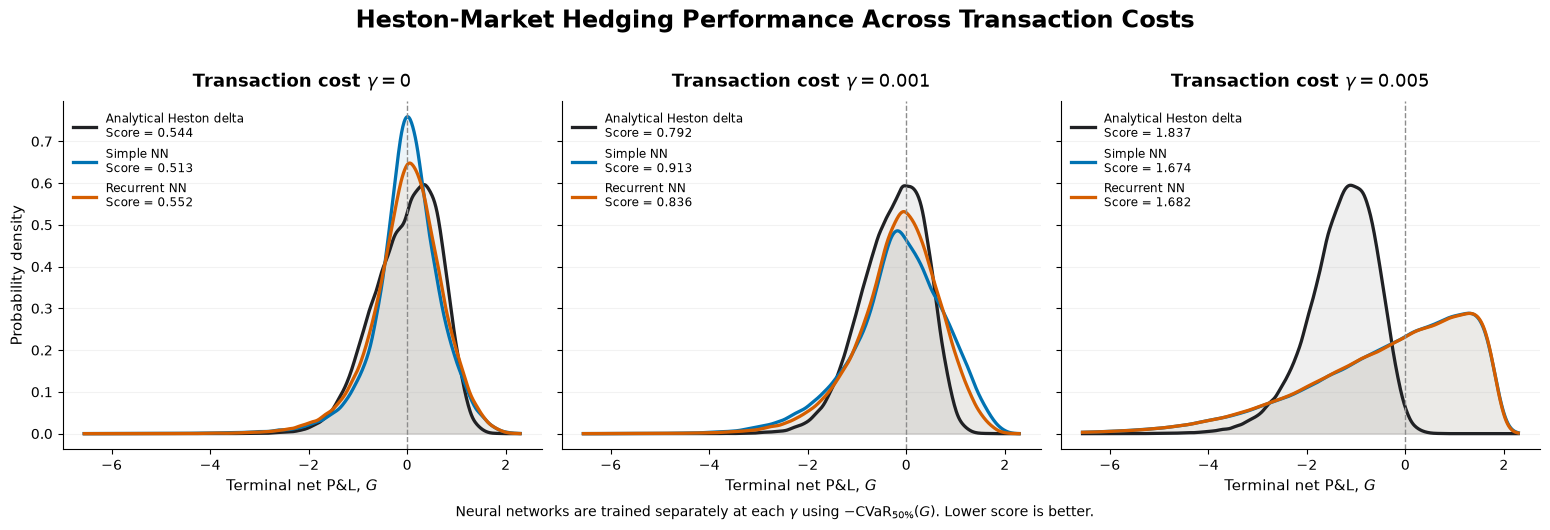

In [8]:
fig, axes = plot_heston_cost_sweep_density(
    heston_cost_sweep,
    confidence=BASE.cvar_confidence,
    output_png=OUTPUT_DIR / "figures" / "heston_pnl_density_cost_sweep.png",
    output_pdf=OUTPUT_DIR / "figures" / "heston_pnl_density_cost_sweep.pdf",
)
plt.show()

**Figure.** Out-of-sample terminal net P&L distributions under Heston stochastic-volatility dynamics. The Simple and Recurrent neural-network policies are trained separately at each proportional transaction-cost level using a CVaR50 objective. Neural-network inputs contain spot price, time to maturity, and an EWMA volatility estimate constructed only from observed stock returns; the Recurrent policy additionally observes its previous hedge position. The analytical Heston delta is an oracle model benchmark evaluated using the simulated latent variance. Scores are defined as $-\mathrm{CVaR}_{50\%}(G)$, with lower values indicating better lower-tail performance.

## References

**[Buehler2019]** Hans Bühler, Lukas Gonon, Josef Teichmann, and Ben Wood. “Deep Hedging.” *Quantitative Finance* 19(8), 1271–1291, 2019. arXiv:1802.03042.

**[BuehlerHorvath2022]** Hans Bühler and Blanka Horvath. *Learning to Trade II: Deep Hedging*. TU Munich lecture notes, 2022.

**[BlackScholes1973]** Fischer Black and Myron Scholes. “The Pricing of Options and Corporate Liabilities.” *Journal of Political Economy* 81(3), 637–654, 1973.

**[Heston1993]** Steven L. Heston. “A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options.” *The Review of Financial Studies* 6(2), 327–343, 1993.

**[KingmaBa2015]** Diederik P. Kingma and Jimmy Ba. “Adam: A Method for Stochastic Optimization.” *International Conference on Learning Representations*, 2015.

**[RiskMetrics1996]** J.P. Morgan/Reuters. *RiskMetrics Technical Document*, 4th ed., 1996.

Full references and BibTeX entries are also available in `docs/references.md` and `docs/references.bib`.